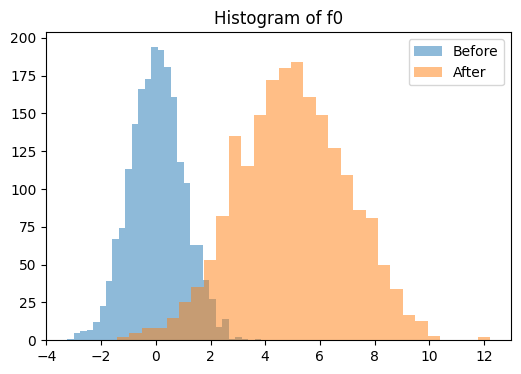

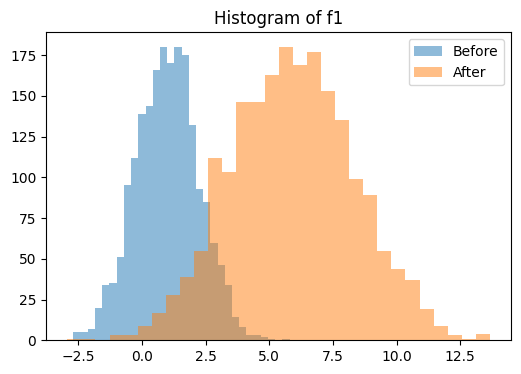

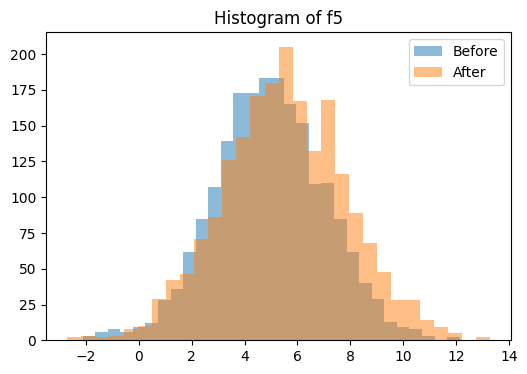

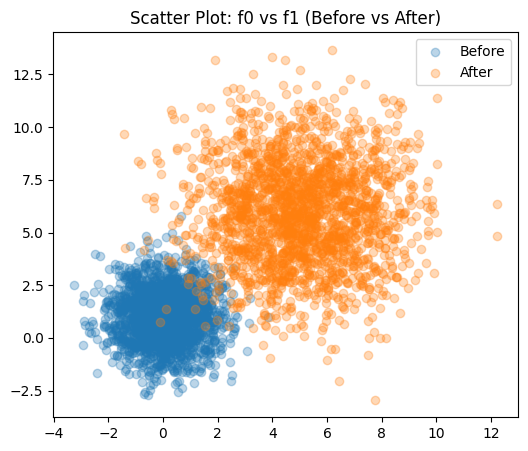

  Feature  KS_Stat     KS_pvalue      AD_Stat
0      f0   0.9135  0.000000e+00  1913.648343
1      f1   0.8310  0.000000e+00  1755.538280
2      f2   0.7790  0.000000e+00  1598.495211
3      f3   0.6965  0.000000e+00  1345.608203
4      f4   0.6420  0.000000e+00  1135.436248
5      f5   0.1155  4.907392e-12    42.989071
6      f6   0.0950  2.832363e-08    22.079282
7      f7   0.0000  1.000000e+00    -1.314002
8      f8   0.0000  1.000000e+00    -1.314002
9      f9   0.0000  1.000000e+00    -1.314002

Features with significant distribution shifts: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6']


/tmp/ipykernel_742/886642830.py:71: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_stat, ad_crit, ad_sig = anderson_ksamp([before, after])
/tmp/ipykernel_742/886642830.py:71: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_stat, ad_crit, ad_sig = anderson_ksamp([before, after])


In [1]:
# ------------------------------------------------------------
# 1. Generate Synthetic Multidimensional Data
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, anderson_ksamp

np.random.seed(42)

n_samples = 2000
n_features = 10

# Each feature has its own mean and variance
means = np.linspace(0, 9, n_features)
stds = np.linspace(1, 3, n_features)

data_before = np.zeros((n_samples, n_features))

for i in range(n_features):
    data_before[:, i] = np.random.normal(means[i], stds[i], n_samples)

df_before = pd.DataFrame(data_before, columns=[f"f{i}" for i in range(n_features)])

# ------------------------------------------------------------
# 2. Introduce Complex Shifts
# ------------------------------------------------------------
data_after = data_before.copy()

# Large shifts in 5 features
for i in range(5):
    data_after[:, i] = np.random.normal(means[i] + 5, stds[i] * 2, n_samples)

# Subtle shifts in 2 features
for i in [5, 6]:
    data_after[:, i] = np.random.normal(means[i] + 0.5, stds[i] * 1.1, n_samples)

df_after = pd.DataFrame(data_after, columns=[f"f{i}" for i in range(n_features)])

# ------------------------------------------------------------
# 3. Visualizations (Histograms + Scatter)
# ------------------------------------------------------------
features_to_plot = ["f0", "f1", "f5"]  # one large shift, one large shift, one subtle shift

for f in features_to_plot:
    plt.figure(figsize=(6,4))
    plt.hist(df_before[f], bins=30, alpha=0.5, label="Before")
    plt.hist(df_after[f], bins=30, alpha=0.5, label="After")
    plt.title(f"Histogram of {f}")
    plt.legend()
    plt.show()

# Scatter plot for two features
plt.figure(figsize=(6,5))
plt.scatter(df_before["f0"], df_before["f1"], alpha=0.3, label="Before")
plt.scatter(df_after["f0"], df_after["f1"], alpha=0.3, label="After")
plt.title("Scatter Plot: f0 vs f1 (Before vs After)")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 4. Statistical Shift Detection
# ------------------------------------------------------------
results = []

for f in df_before.columns:
    before = df_before[f]
    after = df_after[f]

    ks_stat, ks_p = ks_2samp(before, after)
    ad_stat, ad_crit, ad_sig = anderson_ksamp([before, after])

    results.append([f, ks_stat, ks_p, ad_stat])

df_results = pd.DataFrame(results, columns=["Feature", "KS_Stat", "KS_pvalue", "AD_Stat"])
print(df_results)

# ------------------------------------------------------------
# 5. Identify Significant Shifts
# ------------------------------------------------------------
significant_features = df_results[df_results["KS_pvalue"] < 0.05]["Feature"].tolist()
print("\nFeatures with significant distribution shifts:", significant_features)